In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import invert
from scipy.interpolate import splprep, splev
from shapely.geometry import LineString, Point
from scipy.ndimage import center_of_mass
from scipy.spatial.distance import cdist

# Import functions from the utils directory
from utils.snakeFunctions import findSnake, find_endpoints, trace_skeleton, smoothCenterline
from utils.snakeWidth import estimateWidths
from utils.snakeMOI import calculate_moment_of_inertia_voronoi, convert_inertia_pixels_to_meters, convert_geometric_to_physical_inertia

In [2]:
import h5py
import numpy as np

# Constants
dt = 0.071

data_path = '/path/to/the/file/kinematics_images.mat' # <---- CHANGE THIS FOR YOUR COMPUTER

snake_ids = [f'snake{i}' for i in range(1, 7)]
turn_trials = [f'turn{i}' for i in range(1, 7)]

def load_kinematics_data(path):
    """
    Load kinematics_images.mat and return:
      - images: dict mapping turn-trial name -> image stack [height x width x channels x frame]
      - snakes: dict mapping snake name -> dict of scalar/measurement fields
        (includes avgMOI/stdMOI/etc, which are forward-swimming stats used
        as a comparison baseline for the turning MOI computed below)
    """
    images = {}
    snakes = {}

    with h5py.File(path, 'r') as f:
        for trial in turn_trials:
            arr = np.array(f['data'][trial])
            images[trial] = np.transpose(arr, axes=range(arr.ndim - 1, -1, -1))

        fields = ['avgMOI', 'stdMOI', 'avgAng', 'stdAng', 'avgH2T', 'stdH2T',
                  'bodyLength', 'mass', 'px2cm_turn', 'px2cm_fwd']
        for snake_id in snake_ids:
            snakes[snake_id] = {field: f[snake_id][field][()] for field in fields}

    return images, snakes

images, snakes = load_kinematics_data(data_path)

snake_mass = [snakes[s]['mass'] for s in snake_ids]
pixels_in_cm = [snakes[s]['px2cm_turn'] for s in snake_ids]
bodyLength = [snakes[s]['bodyLength'] for s in snake_ids]

allCOM = []
allMOI = []
allSnakes = []

In [3]:
allCOM = []
allMOI = []
allSnakes = []

def prep_frame(img):
    """Convert an RGB frame from the h5py stack into what findSnake expects (BGR, uint8)."""
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

for snake_id, turn_trial in zip(snake_ids, turn_trials):
    img_stack = images[turn_trial]        # [height, width, channels, frame]
    n_frames = img_stack.shape[-1]
    px2cm = snakes[snake_id]['px2cm_turn']
    mass = snakes[snake_id]['mass']

    comList = []
    moiList = []
    snakeList = []

    for frame_idx in range(n_frames):
        img = prep_frame(img_stack[:, :, :, frame_idx])
        # Use image to find the binary image, contour and centerline
        snakeBW, snakeOutline, snakeSkel = findSnake(img)
        # Find endpoints of the centerline
        endpoints = find_endpoints(snakeSkel)
        if len(endpoints) >= 1:
            start_point = endpoints[0]
        else:
            raise ValueError("No endpoints found in the skeleton")
        # Trace the centerline path from start
        ordered_skeleton = trace_skeleton(snakeSkel, start_point)
        # Smooth the centerline and find evenly spaced points
        smoothLine = smoothCenterline(ordered_skeleton)
        # Calculate the center of mass and moment of inertia for the snake
        MOI_pixels, COM = calculate_moment_of_inertia_voronoi(snakeBW, smoothLine)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # img is BGR now, convert back for display
        plt.plot(COM[0], COM[1], 'o', color='#F59300')
        plt.axis('off')
        plt.clf()
        # Convert the moment of inertia from pixels^4 to m^4
        MOI_m = convert_inertia_pixels_to_meters(MOI_pixels, px2cm)
        MOI_kgm = convert_geometric_to_physical_inertia(MOI_m, snakeBW, px2cm, mass)
        comList.append(COM)
        moiList.append(MOI_kgm)
        snakeList.append(smoothLine)

    allCOM.append(comList)
    allMOI.append(moiList)
    allSnakes.append(snakeList)

<Figure size 640x480 with 0 Axes>

In [4]:
def get_scalar(value):
    """Unwrap a MATLAB scalar that h5py may return as shape (1,1)."""
    arr = np.array(value)
    return arr.item() if arr.size == 1 else arr

# Pull forward-swimming stats per snake, in the same snake order as allMOI/allCOM
avgMOI_fwd = [get_scalar(snakes[s]['avgMOI']) for s in snake_ids]
stdMOI_fwd = [get_scalar(snakes[s]['stdMOI']) for s in snake_ids]
avgAng_fwd = [get_scalar(snakes[s]['avgAng']) for s in snake_ids]
stdAng_fwd = [get_scalar(snakes[s]['stdAng']) for s in snake_ids]
avgH2T_fwd = [get_scalar(snakes[s]['avgH2T']) for s in snake_ids]
stdH2T_fwd = [get_scalar(snakes[s]['stdH2T']) for s in snake_ids]

In [5]:
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


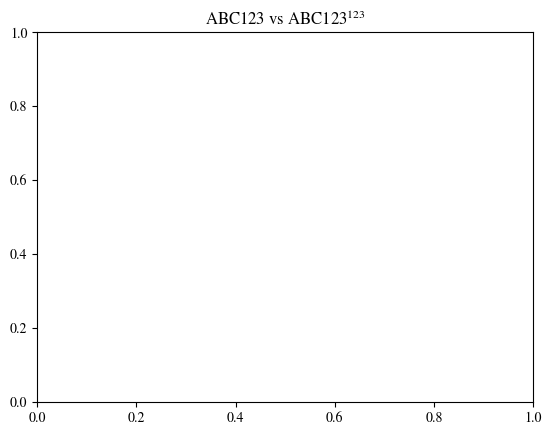

In [6]:
import numpy as np
import scipy.io as sio
import os
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
matplotlib.rcParams.update({'font.size': 14})

In [7]:
allfirst_x = []
allfirst_y = []
alllast_x = []
alllast_y = []

for i in range(0,len(snakes)):
    first_x = []
    first_y = []
    last_x = []
    last_y = []
    
    for j in range(0,len(allSnakes[i])):
        first_x.append(allSnakes[i][j][0,0])
        first_y.append(allSnakes[i][j][0,1])
        last_x.append(allSnakes[i][j][-1,0])
        last_y.append(allSnakes[i][j][-1,1])

    allfirst_x.append(first_x)
    allfirst_y.append(first_y)
    alllast_x.append(last_x)
    alllast_y.append(last_y)

In [8]:
allHead = []
allTail = []

def whichPoint(start_here, point1, point2):
    distance1 = np.sqrt( (start_here[0] - point1[0])**2 + (start_here[1] - point1[1])**2 )
    distance2 = np.sqrt( (start_here[0] - point2[0])**2 + (start_here[1] - point2[1])**2 )

    next_point = point1 if distance1 < distance2 else point2
    
    return next_point

for i in range(0,len(snakes)):
    orderedHead = []
    orderedTail = []

    first_coord = (allfirst_x[i][0],allfirst_y[i][0])        
    last_coord  = ( alllast_x[i][0], alllast_y[i][0])

    orderedHead.append(first_coord)
    orderedTail.append(last_coord)
    
    for j in range(1,len(allfirst_x[i])):
        next1 = (allfirst_x[i][j],allfirst_y[i][j])
        next2 = ( alllast_x[i][j], alllast_y[i][j])
        
        nextHead = whichPoint(orderedHead[j-1],next1,next2)
        nextTail = whichPoint(orderedTail[j-1],next1,next2)

        if nextHead == nextTail:
            print('Error: head and tail are the same, snake =', i, ' frame =', j)

        if ((i == 1) and (j == 14)):
            print('Attempting to fix')
            tmp = nextHead
            nextHead = nextTail
            nextTail = tmp

        orderedHead.append(nextHead)
        orderedTail.append(nextTail)

    allHead.append(orderedHead)
    allTail.append(orderedTail)

Attempting to fix


In [9]:
# To create images of snake with COM, Head or Tail marked
heads = []; tails = []; coms = []
for i in range(0, len(snake_ids)):
    heads_tmp = np.array(allHead[i])
    tails_tmp = np.array(allTail[i])
    com_tmp   = np.array(allCOM[i])   # fixed: was allCOM[0]
    heads.append(heads_tmp)
    tails.append(tails_tmp)
    coms.append(com_tmp)

# Choose which snakes to visualize, e.g. [1, 3] for snake1 and snake3, or None for all
# snakes_to_plot = None  # e.g. [1, 3]
snakes_to_plot = [6]  # e.g. [1, 3]

selected_indices = range(len(turn_trials)) if snakes_to_plot is None else [n - 1 for n in snakes_to_plot]

for i in selected_indices:
    turn_trial = turn_trials[i]
    img_stack = images[turn_trial]
    n_frames = img_stack.shape[-1]
    for j in range(n_frames):
        img = img_stack[:, :, :, j]
        plt.imshow(img)
        plt.plot(coms[i][j,0], coms[i][j,1], 'o', color='darkgray',label='COM')
        plt.plot(heads[i][j,0], heads[i][j,1], 'o', color='deeppink',label='Head')
        plt.plot(tails[i][j,0], tails[i][j,1], 'o', color='orange',label='Tail')
        plt.legend()
        #plt.show()
        plt.clf()

<Figure size 640x480 with 0 Axes>

In [10]:
# Import math Library
import math

distanceCOM = []
velocityCOM = []
accelerationCOM = []

distanceHead = []
velocityHead = []
accelerationHead = []

distanceTail = []
velocityTail = []
accelerationTail = []


for i in range(0,len(snakes)):

    arrayCOM = np.array(allCOM[i])
    arrayHead = np.array(allHead[i])
    arrayTail = np.array(allTail[i])

    x_COM = arrayCOM[:,0]
    y_COM = arrayCOM[:,1]

    distance_COM = np.sqrt( ( x_COM[:-1] - x_COM[1:] )**2 + ( y_COM[:-1] - y_COM[1:] )**2 )
    distance_COM = distance_COM / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_COM = distance_COM / dt
    acceleration_COM = velocity_COM / dt

    distanceCOM.append(distance_COM)
    velocityCOM.append(velocity_COM)
    accelerationCOM.append(acceleration_COM)

    x_Head = arrayHead[:,0]
    y_Head = arrayHead[:,1]

    distance_Head = np.sqrt( ( x_Head[:-1] - x_Head[1:] )**2 + ( y_Head[:-1] - y_Head[1:] )**2 )
    distance_Head = distance_Head / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_Head = distance_Head / dt
    acceleration_Head = velocity_Head / dt

    distanceHead.append(distance_Head)
    velocityHead.append(velocity_Head)
    accelerationHead.append(acceleration_Head)
    
    x_Tail = arrayTail[:,0]
    y_Tail = arrayTail[:,1]

    distance_Tail = np.sqrt( ( x_Tail[:-1] - x_Tail[1:] )**2 + ( y_Tail[:-1] - y_Tail[1:] )**2 )
    distance_Tail = distance_Tail / ( pixels_in_cm[i][0, 0] * 100 )
    velocity_Tail = distance_Tail / dt
    acceleration_Tail = velocity_Tail / dt

    distanceTail.append(distance_Tail)
    velocityTail.append(velocity_Tail)
    accelerationTail.append(acceleration_Tail)


(0.0, 1.6)

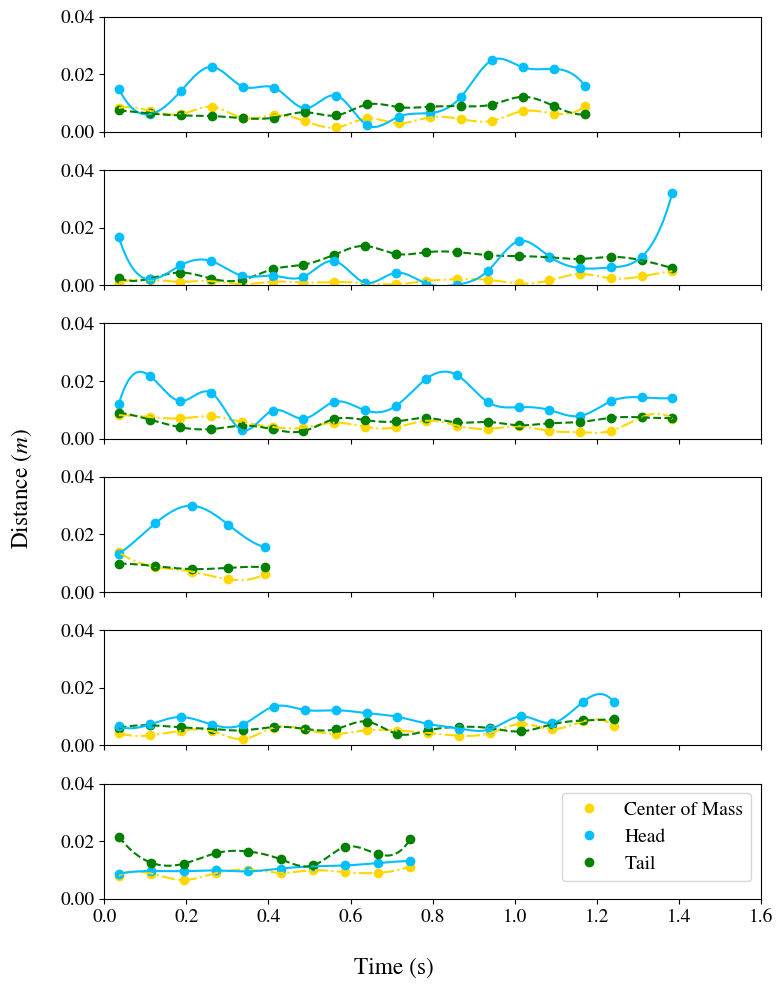

In [11]:
from scipy.interpolate import CubicSpline

color2 = 'deepskyblue'
color1 = 'gold'
color3 = 'green'
time_offset = 0.0355

fig_size = [8, 10]
fig, axs = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

# Head/tail color+linestyle convention per row. Rows 2 and 3 (Snake 3, Snake 4)
# use a swapped convention relative to the others -- preserved from the
# original code pending confirmation of whether this is intentional.
row_style = {
    0: dict(head_color=color2, tail_color=color3, head_line='-',  tail_line='--'),
    1: dict(head_color=color3, tail_color=color2, head_line='--',  tail_line='-'),
    2: dict(head_color=color2, tail_color=color3, head_line='-', tail_line='--'),
    3: dict(head_color=color2, tail_color=color3, head_line='-', tail_line='--'),
    4: dict(head_color=color3, tail_color=color2, head_line='--',  tail_line='-'),
    5: dict(head_color=color2, tail_color=color3, head_line='-',  tail_line='--'),
}

for i in range(6):
    time = np.linspace(0, dt * len(distanceCOM[i]), len(distanceCOM[i])) + time_offset
    time_fine = np.linspace(time.min(), time.max(), 500)

    COM_cs  = CubicSpline(time, distanceCOM[i])
    Head_cs = CubicSpline(time, distanceHead[i])
    Tail_cs = CubicSpline(time, distanceTail[i])

    COM_fine  = COM_cs(time_fine)
    Head_fine = Head_cs(time_fine)
    Tail_fine = Tail_cs(time_fine)

    style = row_style[i]
    is_last = (i == 5)

    axs[i].plot(time, distanceCOM[i], 'o', color=color1,
                label='Center of Mass' if is_last else None)
    axs[i].plot(time, distanceHead[i], 'o', color=style['head_color'],
                label='Head' if is_last else None)
    axs[i].plot(time, distanceTail[i], 'o', color=style['tail_color'],
                label='Tail' if is_last else None)
    axs[i].plot(time_fine, COM_fine, '-.', color=color1)
    axs[i].plot(time_fine, Head_fine, style['head_line'], color=style['head_color'])
    axs[i].plot(time_fine, Tail_fine, style['tail_line'], color=style['tail_color'])

axs[-1].legend()
fig.supxlabel('Time (s)')
fig.supylabel('Distance ($m$)')
plt.ylim(0, 0.04)
plt.xlim(0, 1.6)
#plt.savefig(savePath + '/distance.png', dpi=300)

In [12]:
all_H2T = []
all_ang = []
all_rad = []
all_CT = []
all_CH = []

moiSnakes = [allMOI[0], allMOI[1], allMOI[2], allMOI[3], allMOI[4], allMOI[5]]

for i in range(0,len(snakes)):
    arrayHead = np.array(allHead[i])
    arrayTail = np.array(allTail[i])
    arrayCOM = np.array(allCOM[i])

    H2T = np.sqrt( ( arrayHead[:,0] - arrayTail[:,0] )**2 + ( arrayHead[:,1] - arrayTail[:,1] )**2 )
    H2T = H2T / ( pixels_in_cm[i] * 100 )
    H2T = H2T / bodyLength[i]

    moiSnakes[i] = ( np.array(moiSnakes[i]) / bodyLength[i]**2 ) * 1000

    all_H2T.append(H2T)

    if i == 2:
        dy = arrayTail[:,1] - arrayHead[:,1]
        dx = arrayTail[:,0] - arrayHead[:,0]
    else:
        dy = arrayHead[:,1] - arrayTail[:,1]
        dx = arrayHead[:,0] - arrayTail[:,0]


    rad = np.arctan2(dy, dx)
    rad = np.unwrap(rad)          # remove artificial ±180° jumps
    ang = np.degrees(rad)

    all_ang.append(ang)
    all_rad.append(rad)

    CT = np.sqrt( ( arrayTail[:,0] - arrayCOM[:,0] )**2 + ( arrayTail[:,1] - arrayCOM[:,1] )**2 )
    CT = CT / ( pixels_in_cm[i] * 100 )
    CT = CT / bodyLength[i]

    CH = np.sqrt( ( arrayHead[:,0] - arrayCOM[:,0] )**2 + ( arrayHead[:,1] - arrayCOM[:,1] )**2 )
    CH = CH / ( pixels_in_cm[i] * 100 )
    CH = CH / bodyLength[i]

    all_CT.append(CT)
    all_CH.append(CH)


(-30.0, 180.0)

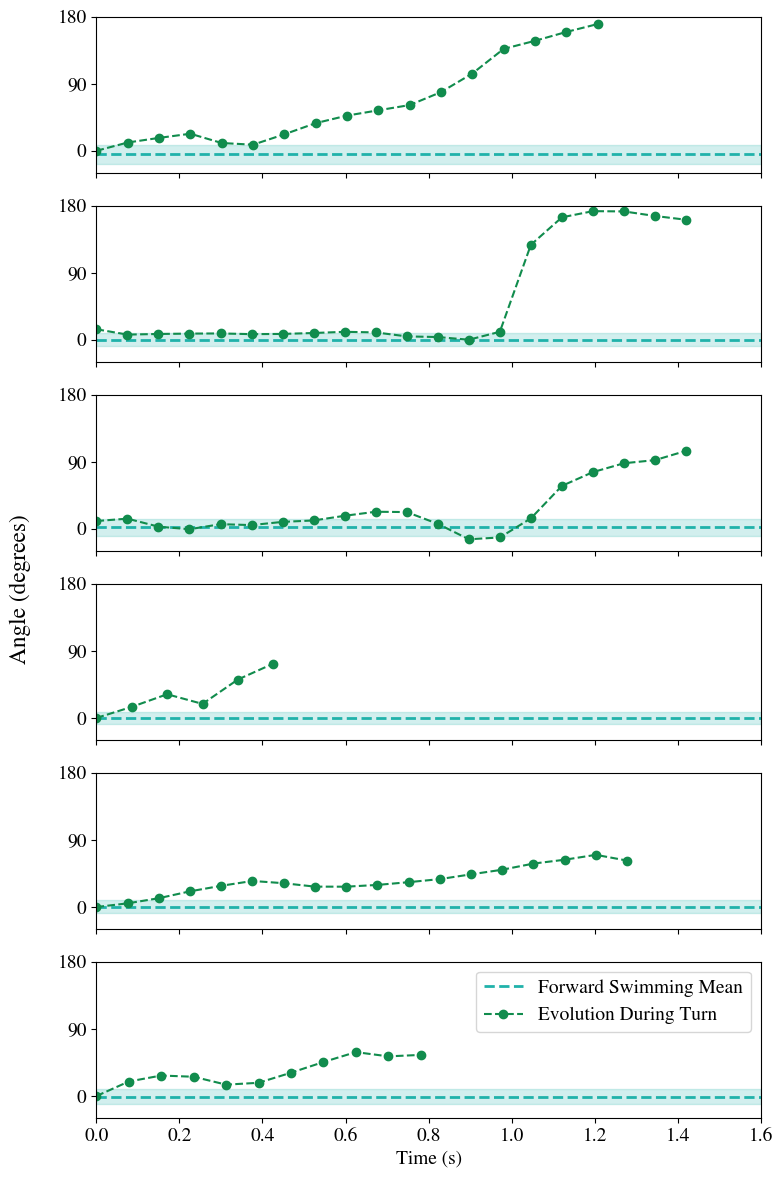

In [13]:
color3 = '#118C4D'
fig_size = [8, 12]

# Plot rows, top to bottom, matching Snakes 1-6 as listed:
#   Snake 1 -> index 0, angle - angle[0]
#   Snake 2 -> index 2, |angle + angle[0]|
#   Snake 3 -> index 1, angle + angle[0]
#   Snake 4 -> index 4, angle - angle[0]
#   Snake 5 -> index 3, angle - angle[0]
#   Snake 6 -> index 5, angle - angle[0]
# NOTE: the add/abs corrections on Snakes 2 and 3 normalize for swimming
# direction, shifting their traces to start near 0 degrees like the others.
row_config = [
    (0, lambda ang: ang - ang[0]),
    (1, lambda ang: np.abs(ang + ang[0])),
    (2, lambda ang: ang + ang[0]),
    (3, lambda ang: ang - ang[0]),
    (4, lambda ang: ang - ang[0]),
    (5, lambda ang: ang - ang[0]),
]

fig, axs = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

for row, (snake_idx, transform) in enumerate(row_config):
    ang = all_ang[snake_idx]
    time = np.linspace(0, dt * len(ang), len(ang))
    ang_transformed = transform(ang)

    is_last = (row == len(row_config) - 1)

    axs[row].axhspan(avgAng_fwd[snake_idx] - stdAng_fwd[snake_idx],
                      avgAng_fwd[snake_idx] + stdAng_fwd[snake_idx],
                      color='lightseagreen', alpha=0.2)
    axs[row].axhline(y=avgAng_fwd[snake_idx], color='lightseagreen', linestyle='--', lw=2,
                      label='Forward Swimming Mean' if is_last else None)
    axs[row].plot(time, ang_transformed, 'o--', color=color3,
                   label='Evolution During Turn' if is_last else None)

axs[-1].legend()
fig.supylabel('Angle (degrees)')
plt.xlabel('Time (s)')
plt.xlim(0, 1.6)
plt.yticks([0, 90, 180], [0, 90, 180])
plt.ylim(-30, 180)
#plt.savefig(savePath + '/angle.png', dpi=300)

([<matplotlib.axis.XTick at 0x162ae0590>,
 [Text(0.38, 0, '1.0'), Text(0.88, 0, '1.5'), Text(1.37, 0, '2.0')])

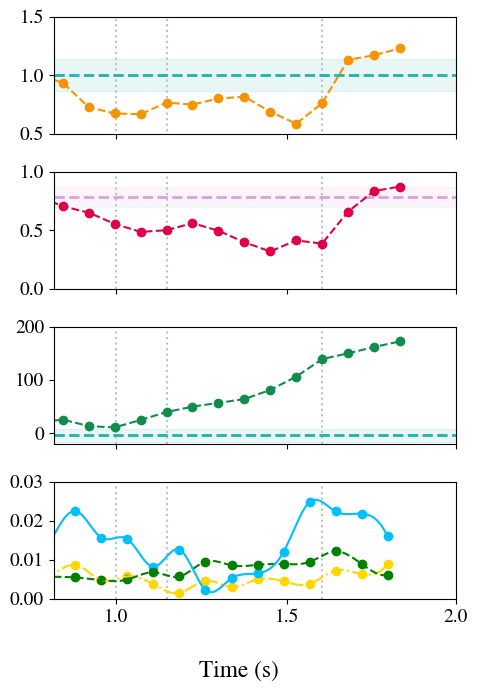

In [14]:
time_snake1 = np.linspace(0,dt*len(distanceCOM[0]),len(distanceCOM[0]))
time_snake1 = time_snake1 + 0.0355
snake1_fine = np.linspace(time_snake1.min(), time_snake1.max(), 500)

COM_cs1 = CubicSpline(time_snake1, np.squeeze(distanceCOM[0]))
Head_cs1 = CubicSpline(time_snake1, np.squeeze(distanceHead[0]))
Tail_cs1 = CubicSpline(time_snake1, np.squeeze(distanceTail[0]))

tail_1 = Tail_cs1(snake1_fine)
head_1 = Head_cs1(snake1_fine)
COM_1  =  COM_cs1(snake1_fine)

tail_vel1 = Tail_cs1.derivative(1)(snake1_fine) # Second derivative
head_vel1 = Head_cs1.derivative(1)(snake1_fine) # Second derivative
COM_vel1  =  COM_cs1.derivative(1)(snake1_fine) # Second derivative

time_moi1 = np.linspace(0,dt*len(np.squeeze(allMOI[0])),len(allMOI[0]))

#vortex_lines = [1, 1.14, 1.639]
vortex_lines = [0.38, 0.528, 0.98]

color_moi = '#F59300'
color_ht = '#DE0049'
color_ang = '#118C4D'
color_aa = 'royalblue'

color2 = 'deepskyblue'
color1 = 'gold'
color3 = 'green'

fig_size = [5,7]
fig, axs = plt.subplots(4, sharex=True, sharey=False, figsize=fig_size, tight_layout = True)
#fig.suptitle('Moment of Inertia')

for i in range(0,len(vortex_lines)):
    axs[0].vlines(vortex_lines[i],ymax=1.5,ymin=0,linestyle=':',color='silver')
    axs[1].vlines(vortex_lines[i],ymax=1,ymin=0,linestyle=':',color='silver')
    axs[2].vlines(vortex_lines[i],ymax=200,ymin=-20,linestyle=':',color='silver')
    axs[3].vlines(vortex_lines[i],ymax=0.03,ymin=0,linestyle=':',color='silver')
    
axs[0].axhspan((avgMOI_fwd[0]-stdMOI_fwd[0])/avgMOI_fwd[0], (avgMOI_fwd[0]+stdMOI_fwd[0])/avgMOI_fwd[0], color='lightseagreen', alpha=0.1)
axs[0].axhline(y=(avgMOI_fwd[0]/avgMOI_fwd[0]), color='lightseagreen', linestyle='--', lw=2, label='Mean')
axs[0].plot(time_moi1, np.squeeze(allMOI[0])/avgMOI_fwd[0],'o--',color=color_moi)
axs[0].axis(ymax=1.5,ymin=0.5)

axs[1].axhspan(avgH2T_fwd[0]-stdH2T_fwd[0], avgH2T_fwd[0]+stdH2T_fwd[0], color='plum', alpha=0.1)
axs[1].axhline(y=avgH2T_fwd[0], color='plum', linestyle='--', lw=2, label='Mean')
axs[1].plot(time_moi1, np.squeeze(all_H2T[0]),'o--',color=color_ht)
axs[1].axis(ymax=1,ymin=0)

axs[2].axhspan(avgAng_fwd[0]-stdAng_fwd[0], avgAng_fwd[0]+stdAng_fwd[0], color='lightseagreen', alpha=0.1)
axs[2].axhline(y=avgAng_fwd[0], color='lightseagreen', linestyle='--', lw=2, label='Mean')
axs[2].plot(time_moi1, np.squeeze(all_ang[0])+180,'o--',color=color_ang)
axs[2].axis(ymax=200,ymin=-20)

axs[3].plot(time_snake1, distanceCOM[0],'o',color=color1)
axs[3].plot(time_snake1, distanceHead[0],'o',color=color2)
axs[3].plot(time_snake1, distanceTail[0],'o',color=color3)

axs[3].plot(snake1_fine,  COM_1, '-.', color=color1)
axs[3].plot(snake1_fine, tail_1, '--',color=color3)
axs[3].plot(snake1_fine, head_1, '-',color=color2)
axs[3].axis(ymax=0.03,ymin=0)

fig.supxlabel('Time (s)')
plt.xlim(0.20,1.37)
plt.xticks([0.38, 0.88, 1.37],[1.0, 1.5, 2.0])
#plt.ylim(0.25,1.5)
#plt.savefig(savePath + '/testsummary.png',dpi=300)

(0.0, 1.6)

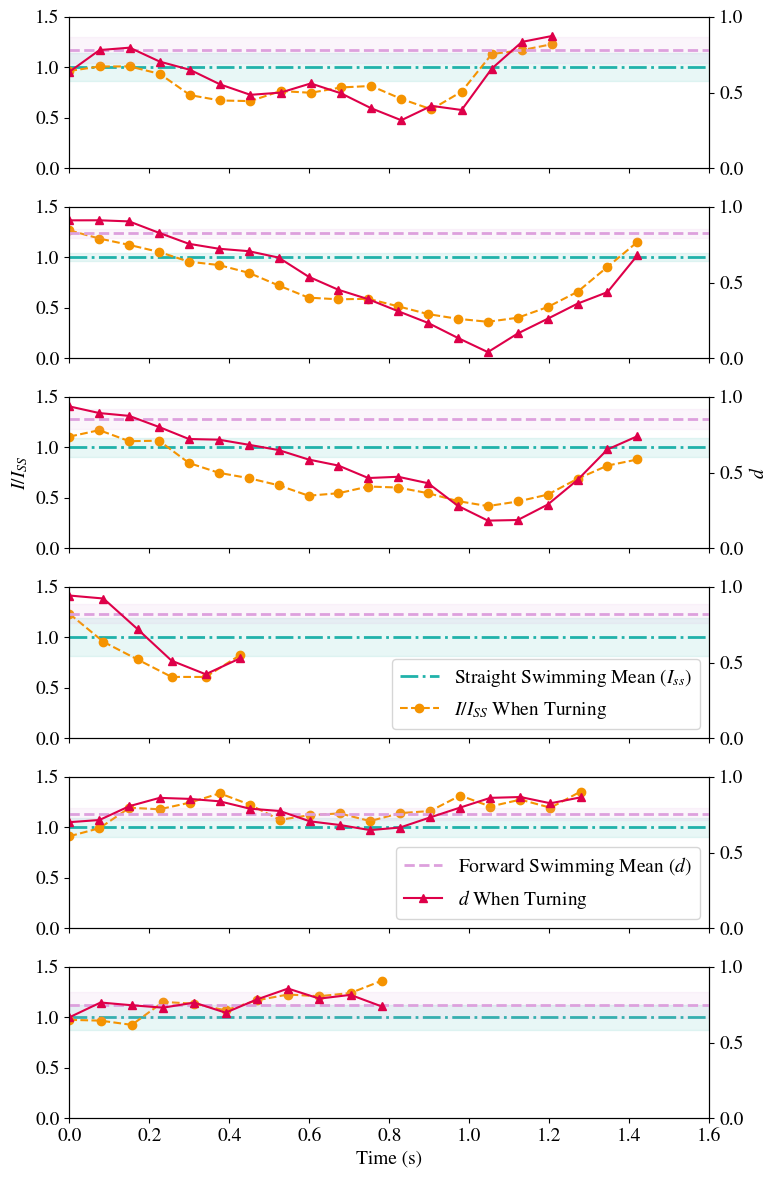

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Color definitions and layout settings
color1 = '#F59300'
color2 = '#DE0049'
fig_size = [8, 12]
dt = 0.071

fig, axes = plt.subplots(6, sharex=True, sharey=True, figsize=fig_size, tight_layout=True)

for i, ax in enumerate(axes):
    ax_twin = ax.twinx()

    # Flatten inputs to 1D arrays
    h2t = np.squeeze(all_H2T[i])
    moi_raw = np.squeeze(allMOI[i])

    # Time array generation based on squeezed 1D length
    time = np.linspace(0, dt * len(h2t), len(h2t))

    # Normalized MOI values
    moi_mean = avgMOI_fwd[i]
    moi_std = stdMOI_fwd[i]
    moi_norm = moi_raw / moi_mean

    # H2T values
    h2t_mean = avgH2T_fwd[i]
    h2t_std = stdH2T_fwd[i]

    # --- Left Axis: Normalized MOI ---
    ax.axhspan((moi_mean - moi_std) / moi_mean, (moi_mean + moi_std) / moi_mean,
               color='lightseagreen', alpha=0.1)
    ax.axhline(y=1.0, color='lightseagreen', linestyle='-.', lw=2,
               label='Straight Swimming Mean ($I_{ss}$)' if i == 3 else None)
    ax.plot(time, moi_norm, 'o--', color=color1,
            label='$I/I_{SS}$ When Turning' if i == 3 else None)
    ax.set_ylim(0, 1.5)

    # --- Right Axis: Head-to-Tail Distance (H2T) ---
    ax_twin.axhspan(h2t_mean - h2t_std, h2t_mean + h2t_std,
                    color='plum', alpha=0.1)
    ax_twin.axhline(y=h2t_mean, color='plum', linestyle='--', lw=2,
                    label='Forward Swimming Mean ($d$)' if i == 4 else None)
    ax_twin.plot(time, h2t, '^-', color=color2,
                 label='$d$ When Turning' if i == 4 else None)
    ax_twin.set_ylim(0, 1)

    # Axis labels & legends
    if i == 2:  # Middle plot y-axis labels
        ax.set_ylabel('$I/I_{SS}$')
        ax_twin.set_ylabel('$d$')

    if i in [3, 4]:
        (ax if i == 3 else ax_twin).legend(loc='lower right')

    if i == 5:  # Bottom x-axis label
        ax.set_xlabel('Time (s)')

plt.xlim(0, 1.6)
# plt.savefig(savePath + '/MOI_and_h2t.png', dpi=300)